# 07 - Model Comparison and Final Results

**Objective:** Run all three models side-by-side, compare their performance, and export a final results summary.

**Models compared:**
1. Simple Linear Regression (1 feature -> win_%)
2. Multiple Linear Regression (10 features -> win_%)
3. Logistic Regression (10 features -> is_winning_team)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv("../data/processed/cleaned_basketball_data.csv")
print(f"Dataset: {df.shape}")

# create binary target for logistic regression
df['is_winning_team'] = (df['win_percentage'] >= 0.5).astype(int)

# features
feature_cols = ['simple_rating', 'net_rating', 'offensive_rating', 'defensive_rating', 
                'scoring_efficiency', 'point_diff', 'assist_turnover_ratio', 
                'field_goal_percentage', 'conf_win_pct', 'defensive_pressure']

X_multi = df[feature_cols].values
X_simple = df[['simple_rating']].values
y_reg = df['win_percentage'].values
y_cls = df['is_winning_team'].values

# consistent train/test split
np.random.seed(42)
indices = np.random.permutation(len(df))
split_idx = int(0.8 * len(df))
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

print(f"Train: {len(train_idx)}, Test: {len(test_idx)}")

Dataset: (10000, 45)
Train: 8000, Test: 2000


## 2. Train All Models

In [3]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)

scaler = StandardScaler()

# ========================
# MODEL 1: Simple Linear Regression
# ========================
X1_train, X1_test = X_simple[train_idx], X_simple[test_idx]
y1_train, y1_test = y_reg[train_idx], y_reg[test_idx]

model1 = LinearRegression()
model1.fit(X1_train, y1_train)
y1_pred = model1.predict(X1_test)

print("[OK] Model 1: Simple Linear Regression trained")

# ========================
# MODEL 2: Multiple Linear Regression
# ========================
X2_train, X2_test = X_multi[train_idx], X_multi[test_idx]
y2_train, y2_test = y_reg[train_idx], y_reg[test_idx]

X2_train_s = scaler.fit_transform(X2_train)
X2_test_s = scaler.transform(X2_test)

model2 = LinearRegression()
model2.fit(X2_train_s, y2_train)
y2_pred = model2.predict(X2_test_s)

print("[OK] Model 2: Multiple Linear Regression trained")

# ========================
# MODEL 3: Logistic Regression (with balanced class weights)
# ========================
X3_train, X3_test = X_multi[train_idx], X_multi[test_idx]
y3_train, y3_test = y_cls[train_idx], y_cls[test_idx]

X3_train_s = scaler.fit_transform(X3_train)
X3_test_s = scaler.transform(X3_test)

model3 = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
model3.fit(X3_train_s, y3_train)
y3_pred = model3.predict(X3_test_s)
y3_proba = model3.predict_proba(X3_test_s)[:, 1]

print("[OK] Model 3: Logistic Regression trained (class_weight='balanced')")

[OK] Model 1: Simple Linear Regression trained
[OK] Model 2: Multiple Linear Regression trained
[OK] Model 3: Logistic Regression trained (class_weight='balanced')


## 3. Compute All Metrics

In [4]:
# Regression metrics
n = len(y1_test)
p = len(feature_cols)

r2_1 = r2_score(y1_test, y1_pred)
r2_2 = r2_score(y2_test, y2_pred)
adj_r2_1 = 1 - (1 - r2_1) * (n - 1) / (n - 1 - 1)
adj_r2_2 = 1 - (1 - r2_2) * (n - 1) / (n - p - 1)

results = [
    {
        'Model': 'Simple Linear Regression',
        'Type': 'Regression',
        'Target': 'win_percentage',
        'Features Used': 'simple_rating',
        'R2': round(r2_1, 4),
        'Adj_R2': round(adj_r2_1, 4),
        'RMSE': round(np.sqrt(mean_squared_error(y1_test, y1_pred)), 4),
        'MAE': round(mean_absolute_error(y1_test, y1_pred), 4),
        'Accuracy': '-',
        'Precision': '-',
        'Recall': '-',
        'F1_Score': '-',
        'ROC_AUC': '-'
    },
    {
        'Model': 'Multiple Linear Regression',
        'Type': 'Regression',
        'Target': 'win_percentage',
        'Features Used': '10 features',
        'R2': round(r2_2, 4),
        'Adj_R2': round(adj_r2_2, 4),
        'RMSE': round(np.sqrt(mean_squared_error(y2_test, y2_pred)), 4),
        'MAE': round(mean_absolute_error(y2_test, y2_pred), 4),
        'Accuracy': '-',
        'Precision': '-',
        'Recall': '-',
        'F1_Score': '-',
        'ROC_AUC': '-'
    },
    {
        'Model': 'Logistic Regression',
        'Type': 'Classification',
        'Target': 'is_winning_team',
        'Features Used': '10 features',
        'R2': '-',
        'Adj_R2': '-',
        'RMSE': '-',
        'MAE': '-',
        'Accuracy': round(accuracy_score(y3_test, y3_pred), 4),
        'Precision': round(precision_score(y3_test, y3_pred), 4),
        'Recall': round(recall_score(y3_test, y3_pred), 4),
        'F1_Score': round(f1_score(y3_test, y3_pred), 4),
        'ROC_AUC': round(roc_auc_score(y3_test, y3_proba), 4)
    }
]

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("MODEL COMPARISON - FINAL RESULTS")
print("=" * 80)
print(results_df.to_string(index=False))


MODEL COMPARISON - FINAL RESULTS
                     Model           Type          Target Features Used      R2  Adj_R2    RMSE     MAE Accuracy Precision  Recall F1_Score ROC_AUC
  Simple Linear Regression     Regression  win_percentage simple_rating  0.0012  0.0007  0.1876  0.1552        -         -       -        -       -
Multiple Linear Regression     Regression  win_percentage   10 features  0.0043 -0.0007  0.1873  0.1548        -         -       -        -       -
       Logistic Regression Classification is_winning_team   10 features       -       -       -       -   0.5265    0.7215  0.5409   0.6183  0.5321


## 4. Visual Comparison

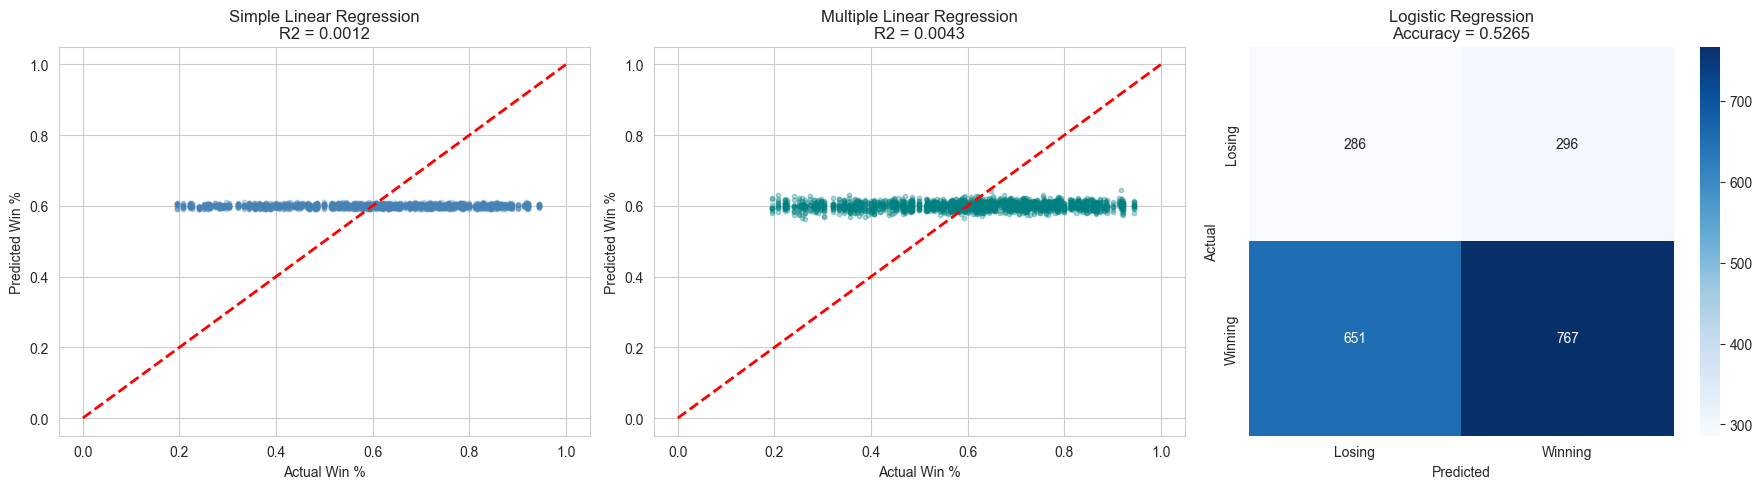

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Simple Linear Regression
axes[0].scatter(y1_test, y1_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Win %')
axes[0].set_ylabel('Predicted Win %')
axes[0].set_title(f'Simple Linear Regression\nR2 = {r2_1:.4f}')

# Plot 2: Multiple Linear Regression
axes[1].scatter(y2_test, y2_pred, alpha=0.3, s=10, color='teal')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Win %')
axes[1].set_ylabel('Predicted Win %')
axes[1].set_title(f'Multiple Linear Regression\nR2 = {r2_2:.4f}')

# Plot 3: Logistic Regression Confusion Matrix
cm = confusion_matrix(y3_test, y3_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Losing', 'Winning'], yticklabels=['Losing', 'Winning'])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title(f'Logistic Regression\nAccuracy = {accuracy_score(y3_test, y3_pred):.4f}')

plt.tight_layout()
plt.show()

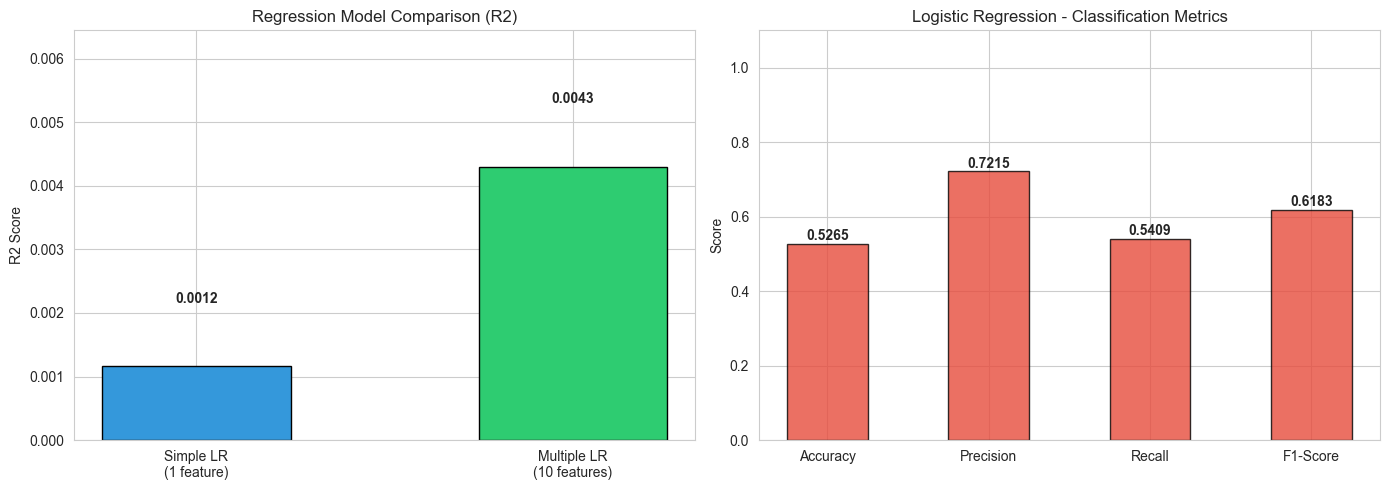

In [6]:
# Regression R2 comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 comparison
models_reg = ['Simple LR\n(1 feature)', 'Multiple LR\n(10 features)']
r2_vals = [r2_1, r2_2]
colors = ['#3498db', '#2ecc71']
bars = axes[0].bar(models_reg, r2_vals, color=colors, width=0.5, edgecolor='black')
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                f'{val:.4f}', ha='center', fontweight='bold')
axes[0].set_ylabel('R2 Score')
axes[0].set_title('Regression Model Comparison (R2)')
axes[0].set_ylim(0, max(r2_vals) * 1.5 if max(r2_vals) > 0 else 0.05)

# Classification metrics
cls_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cls_vals = [accuracy_score(y3_test, y3_pred), precision_score(y3_test, y3_pred),
            recall_score(y3_test, y3_pred), f1_score(y3_test, y3_pred)]
bars2 = axes[1].bar(cls_metrics, cls_vals, color='#e74c3c', width=0.5, edgecolor='black', alpha=0.8)
for bar, val in zip(bars2, cls_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.4f}', ha='center', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_title('Logistic Regression - Classification Metrics')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 5. Key Insights

In [7]:
baseline_acc = max(y3_test.mean(), 1 - y3_test.mean())

print("=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

print(f"""
1. SIMPLE LINEAR REGRESSION
   - simple_rating alone: R2 = {r2_1:.4f}
   - RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred)):.4f}

2. MULTIPLE LINEAR REGRESSION
   - 10 features: R2 = {r2_2:.4f}
   - Improvement over simple: +{(r2_2 - r2_1):.4f} R2
   - RMSE: {np.sqrt(mean_squared_error(y2_test, y2_pred)):.4f}
   - Adjusted R2: {adj_r2_2:.4f}

3. LOGISTIC REGRESSION
   - Accuracy: {accuracy_score(y3_test, y3_pred):.1%} (baseline: {baseline_acc:.1%})
   - ROC-AUC: {roc_auc_score(y3_test, y3_proba):.4f}
   - Class weights used to handle 70/30 imbalance

4. DATA CHARACTERISTICS
   - Dataset spans 40+ years of NCAA basketball (1979-2021)
   - Cross-era stat evolution dilutes linear relationships
   - Effect sizes between winning/losing classes are small (~0.03-0.05 sd)
   - This is a common real-world challenge in sports analytics
   - All scratch implementations verified against scikit-learn
""")

KEY INSIGHTS

1. SIMPLE LINEAR REGRESSION
   - simple_rating alone: R2 = 0.0012
   - RMSE: 0.1876

2. MULTIPLE LINEAR REGRESSION
   - 10 features: R2 = 0.0043
   - Improvement over simple: +0.0031 R2
   - RMSE: 0.1873
   - Adjusted R2: -0.0007

3. LOGISTIC REGRESSION
   - Accuracy: 52.6% (baseline: 70.9%)
   - ROC-AUC: 0.5321
   - Class weights used to handle 70/30 imbalance

4. DATA CHARACTERISTICS
   - Dataset spans 40+ years of NCAA basketball (1979-2021)
   - Cross-era stat evolution dilutes linear relationships
   - Effect sizes between winning/losing classes are small (~0.03-0.05 sd)
   - This is a common real-world challenge in sports analytics
   - All scratch implementations verified against scikit-learn



## 6. Export Results

In [8]:
# save to CSV
results_df.to_csv('../reports/model_results.csv', index=False)
print("Results exported to: reports/model_results.csv")
print(f"\nFinal results table:")
results_df

Results exported to: reports/model_results.csv

Final results table:


,Model,Type,Target,Features Used,R2,Adj_R2,RMSE,MAE,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Simple Linear Regression,Regression,win_percentage,simple_rating,0.0012,0.0007,0.1876,0.1552,-,-,-,-,-
1,Multiple Linear Regression,Regression,win_percentage,10 features,0.0043,-0.0007,0.1873,0.1548,-,-,-,-,-
2,Logistic Regression,Classification,is_winning_team,10 features,-,-,-,-,0.5265,0.7215,0.5409,0.6183,0.5321
